# Premier League Match Prediction - Exploratory Data Analysis (Wes)

## Objective

This notebook is a complementary EDA to `jero_eda.ipynb`. Rather than repeating the dataset overview, target balance, and home-advantage analysis covered there, this notebook digs into:

1. Goal-scoring patterns
2. How in-match statistics separate outcomes (and why that matters for feature design)
3. Half-time to full-time result transitions
4. A deep dive on draws, the hardest class to predict
5. Referee tendencies
6. A signal check on the engineered features in `epl_features.csv`
7. Data quality items to handle before modeling (warm-up rows, leakage)

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/epl_combined_cleaned.csv", parse_dates=["Date"])
features = pd.read_csv("../data/processed/epl_features.csv", parse_dates=["Date"])

print(f"Cleaned matches: {df.shape}")
print(f"Feature dataset: {features.shape}")

Cleaned matches: (3800, 25)
Feature dataset: (3800, 149)


## 2. Goal-Scoring Patterns

Match outcomes are ultimately produced by goals, so understanding how goals are distributed sets expectations for what any model can achieve.

In [2]:
df["total_goals"] = df["FTHG"] + df["FTAG"]

print(f"Avg home goals: {df['FTHG'].mean():.2f}")
print(f"Avg away goals: {df['FTAG'].mean():.2f}")
print(f"Avg total goals: {df['total_goals'].mean():.2f}")
print(f"Over 2.5 goals: {(df['total_goals'] > 2.5).mean() * 100:.1f}% of matches")

Avg home goals: 1.56
Avg away goals: 1.28
Avg total goals: 2.83
Over 2.5 goals: 54.4% of matches


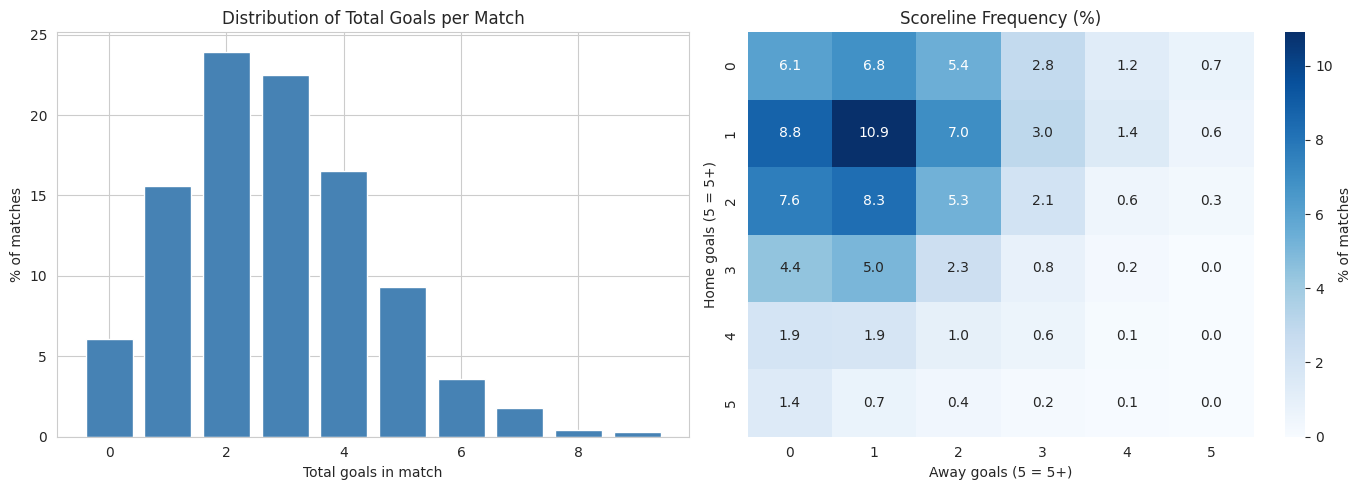

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

goal_counts = df["total_goals"].value_counts(normalize=True).sort_index()
axes[0].bar(goal_counts.index, goal_counts.values * 100, color="steelblue")
axes[0].set_xlabel("Total goals in match")
axes[0].set_ylabel("% of matches")
axes[0].set_title("Distribution of Total Goals per Match")

score_grid = pd.crosstab(df["FTHG"].clip(upper=5), df["FTAG"].clip(upper=5), normalize=True) * 100
sns.heatmap(score_grid, annot=True, fmt=".1f", cmap="Blues", ax=axes[1], cbar_kws={"label": "% of matches"})
axes[1].set_xlabel("Away goals (5 = 5+)")
axes[1].set_ylabel("Home goals (5 = 5+)")
axes[1].set_title("Scoreline Frequency (%)")

plt.tight_layout()
plt.show()

### Findings

- Matches average roughly 2.8 total goals, and just over half of matches finish over 2.5 goals.
- The most common individual scorelines are low-scoring (1-1, 1-0, 2-1, 2-0), which is why single-match outcomes are noisy: one goal frequently changes the result class entirely.
- The scoreline heatmap is asymmetric toward the home side, consistent with the home advantage documented in `jero_eda.ipynb`.

## 3. In-Match Statistics vs Outcome

These statistics are only known after the match, so they cannot be used directly as features. However, if they separate outcomes cleanly, their rolling historical averages (which is exactly what the feature engineering pipeline builds) should carry predictive signal.

In [4]:
df["shot_diff"] = df["HS"] - df["AS"]
df["sot_diff"] = df["HST"] - df["AST"]
df["corner_diff"] = df["HC"] - df["AC"]

stat_summary = df.groupby("FTR")[["shot_diff", "sot_diff", "corner_diff"]].mean().reindex(["H", "D", "A"]).round(2)
stat_summary

,shot_diff,sot_diff,corner_diff
FTR,,,
H,5.30,2.90,1.37
D,2.29,0.49,1.22
A,-1.60,-2.06,0.26


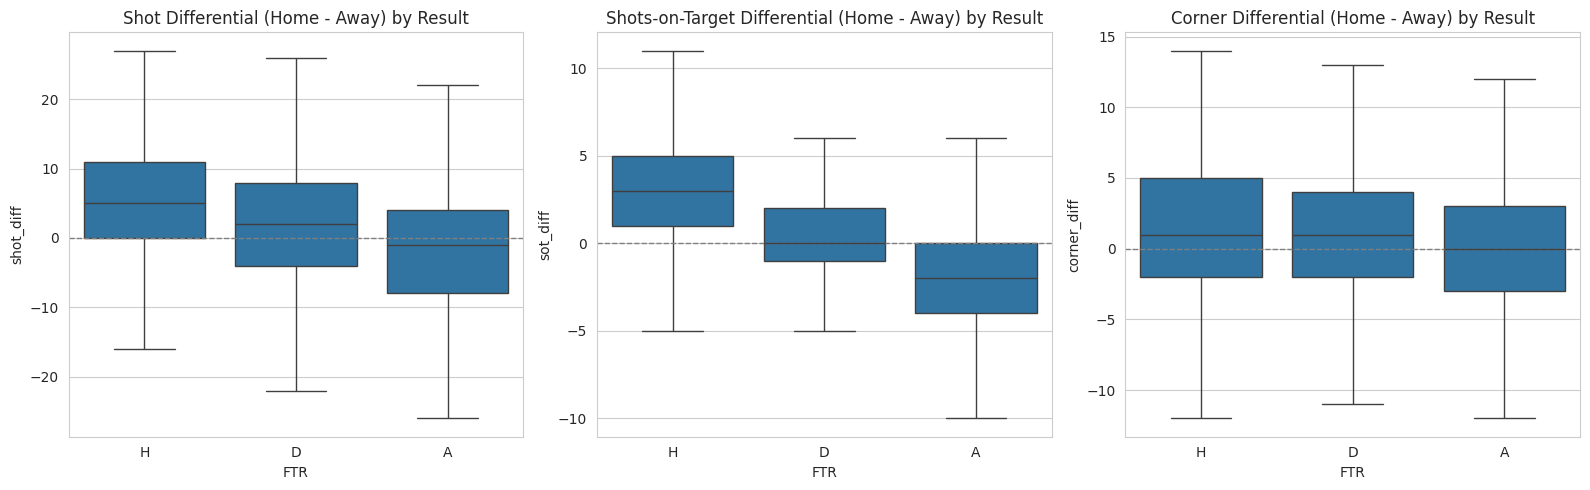

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ["shot_diff", "sot_diff", "corner_diff"],
    ["Shot Differential", "Shots-on-Target Differential", "Corner Differential"],
):
    sns.boxplot(x="FTR", y=col, data=df, order=["H", "D", "A"], ax=ax, showfliers=False)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{title} (Home - Away) by Result")

plt.tight_layout()
plt.show()

### Findings

- Home wins come with an average shot differential of about +5.3 and shots-on-target differential of about +2.9; away wins flip both negative.
- Shots on target is the cleanest separator of the three, which supports the heavy use of SOT-based rolling features in the feature set.
- Notably, drawn matches still show home teams outshooting their opponents (+2.3 shots on average). Home sides tend to dominate territory even when they fail to win, which is one reason draws are structurally difficult to identify.
- Distributions overlap heavily across all three classes: superior underlying statistics raise the probability of winning but never guarantee it. Probabilistic evaluation (log loss) will be more informative than accuracy alone.

## 4. Shot Conversion

In [6]:
total_goals = df["FTHG"].sum() + df["FTAG"].sum()
total_shots = df["HS"].sum() + df["AS"].sum()
total_sot = df["HST"].sum() + df["AST"].sum()

print(f"Goals per shot: {total_goals / total_shots:.3f}")
print(f"Goals per shot on target: {total_goals / total_sot:.3f}")
print(f"Home conversion (goals per SOT): {df['FTHG'].sum() / df['HST'].sum():.3f}")
print(f"Away conversion (goals per SOT): {df['FTAG'].sum() / df['AST'].sum():.3f}")

Goals per shot: 0.112
Goals per shot on target: 0.322
Home conversion (goals per SOT): 0.326
Away conversion (goals per SOT): 0.318


### Findings

- Roughly 1 in 9 shots and 1 in 3 shots on target becomes a goal, and home/away conversion rates are nearly identical.
- Home advantage therefore operates through volume (more shots created) rather than better finishing. Rolling shot-volume features should capture most of it.

## 5. Half-Time to Full-Time Transitions

How often does the half-time result hold? This quantifies within-match volatility, which bounds how predictable full-time results can be from pre-match information.

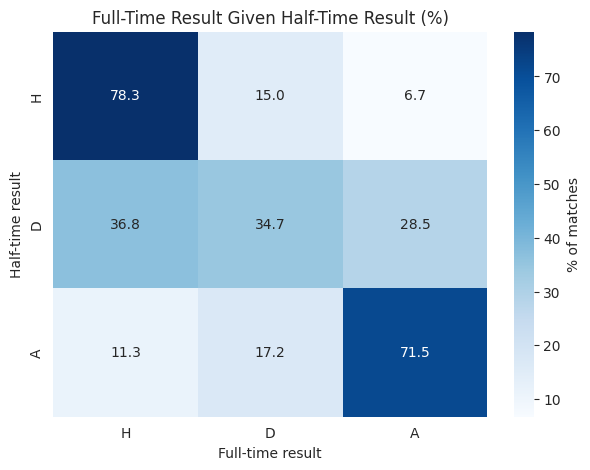

Home half-time lead converted to win: 78.3%
Away half-time lead converted to win: 71.5%


In [7]:
ht_ft = pd.crosstab(df["HTR"], df["FTR"], normalize="index").reindex(index=["H", "D", "A"], columns=["H", "D", "A"]) * 100

plt.figure(figsize=(7, 5))
sns.heatmap(ht_ft, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% of matches"})
plt.xlabel("Full-time result")
plt.ylabel("Half-time result")
plt.title("Full-Time Result Given Half-Time Result (%)")
plt.show()

leader_holds = (df.loc[df["HTR"] == "H", "FTR"] == "H").mean()
away_holds = (df.loc[df["HTR"] == "A", "FTR"] == "A").mean()
print(f"Home half-time lead converted to win: {leader_holds * 100:.1f}%")
print(f"Away half-time lead converted to win: {away_holds * 100:.1f}%")

### Findings

- Half-time leads are strong but far from decisive; a meaningful share of matches change class in the second half.
- Matches level at half-time split fairly evenly across all three outcomes, reinforcing that a large fraction of matches are genuinely close to coin flips.
- This is useful context for setting realistic accuracy targets: published academic and industry models on this type of data typically reach the low-to-mid 50s percent accuracy.

## 6. Draw Deep-Dive

Draws make up roughly a quarter of matches but behave very differently from wins: they are not caused by a team being in draw-like form, they mostly happen when two teams cancel out. This section quantifies how weak the draw signal is in the engineered features.

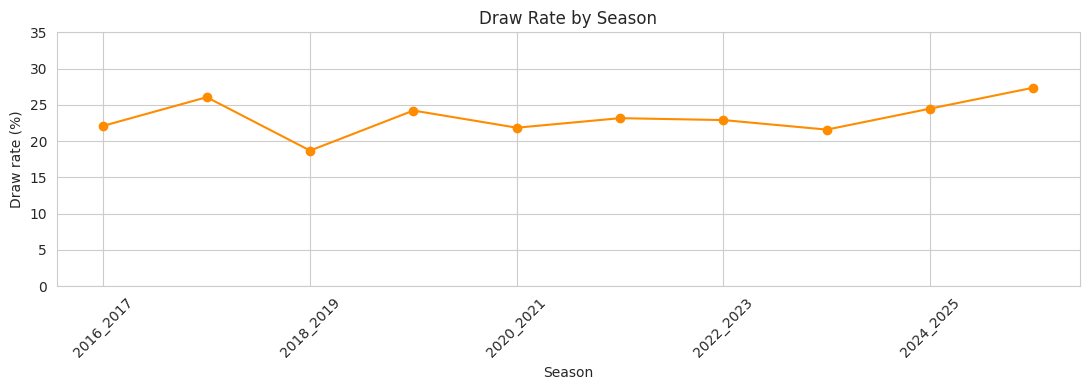

In [8]:
draw_rate_by_season = df.groupby("Season")["FTR"].apply(lambda s: (s == "D").mean() * 100)

plt.figure(figsize=(11, 4))
draw_rate_by_season.plot(marker="o", color="darkorange")
plt.ylabel("Draw rate (%)")
plt.title("Draw Rate by Season")
plt.ylim(0, 35)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
warm_up = features["home_overall_points_last_5"].isna() | features["away_overall_points_last_5"].isna()
model_rows = features[~warm_up].copy()

numeric = model_rows.select_dtypes(include=np.number).drop(
    columns=["MatchID", "target_result_encoded", "target_home_win", "target_draw", "target_away_win", "FTHG", "FTAG"],
    errors="ignore",
)

corr_home = numeric.corrwith(model_rows["target_home_win"]).sort_values(key=abs, ascending=False)
corr_draw = numeric.corrwith(model_rows["target_draw"]).sort_values(key=abs, ascending=False)

print("Strongest correlation with HOME WIN:", f"{corr_home.iloc[0]:.3f}", f"({corr_home.index[0]})")
print("Strongest correlation with DRAW:    ", f"{corr_draw.iloc[0]:.3f}", f"({corr_draw.index[0]})")

Strongest correlation with HOME WIN: 0.321 (diff_overall_goal_diff_last_10)
Strongest correlation with DRAW:     0.057 (home_overall_shots_against_last_5)


### Findings

- The draw rate is fairly stable season to season, hovering in the low-to-mid 20s percent.
- No engineered feature correlates with draws at better than about |r| = 0.06, versus about 0.32 for home wins. Draws are close to unlearnable from form-based features alone.
- Expected consequence: a classifier trained on these features will under-predict draws, and per-class recall should be reported alongside overall accuracy. Options to explore later include class weighting, ordinal framing (A < D < H), or modeling goals directly (e.g., Poisson) and deriving outcome probabilities.

## 7. Referee Tendencies

The feature set includes referee-based features (`referee_matches_before`, rolling fouls/cards). This section checks whether referees actually differ enough for those features to matter.

In [10]:
df["total_cards"] = df["HY"] + df["AY"] + df["HR"] + df["AR"]
df["total_fouls"] = df["HF"] + df["AF"]

ref_summary = (
    df.groupby("Referee")
    .agg(matches=("FTR", "count"), avg_cards=("total_cards", "mean"), avg_fouls=("total_fouls", "mean"))
    .query("matches >= 50")
    .sort_values("avg_cards", ascending=False)
)
print(f"Referees with 50+ matches: {len(ref_summary)}")
ref_summary.head(10).round(2)

Referees with 50+ matches: 25


,matches,avg_cards,avg_fouls
Referee,,,
J Brooks,74,4.45,21.77
D England,99,4.10,21.89
T Bramall,52,4.08,22.38
P Bankes,115,4.06,21.64
M Salisbury,61,3.98,22.74
D Coote,112,3.97,23.48
M Dean,162,3.97,21.19
R Jones,110,3.96,22.57
S Barrott,62,3.95,20.19


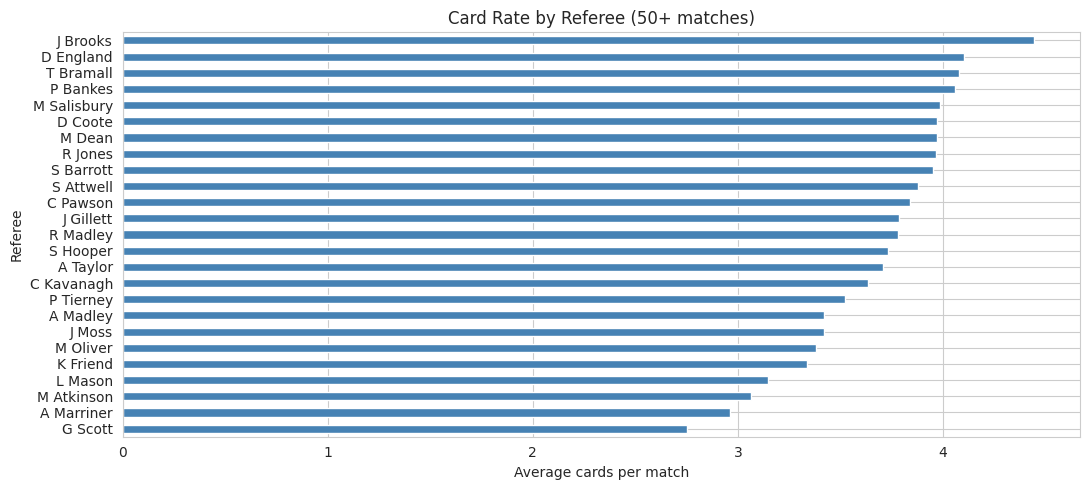

In [11]:
plt.figure(figsize=(11, 5))
ref_summary["avg_cards"].sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Average cards per match")
plt.title("Card Rate by Referee (50+ matches)")
plt.tight_layout()
plt.show()

### Findings

- Referees with large samples differ meaningfully in cards per match, roughly from the low 3s to the mid 4s.
- Cards and fouls relate to match temperament rather than directly to results, so referee features are likely secondary. They are worth keeping for a first model but are candidates for pruning if feature importance is low.

## 8. Engineered Feature Signal Check

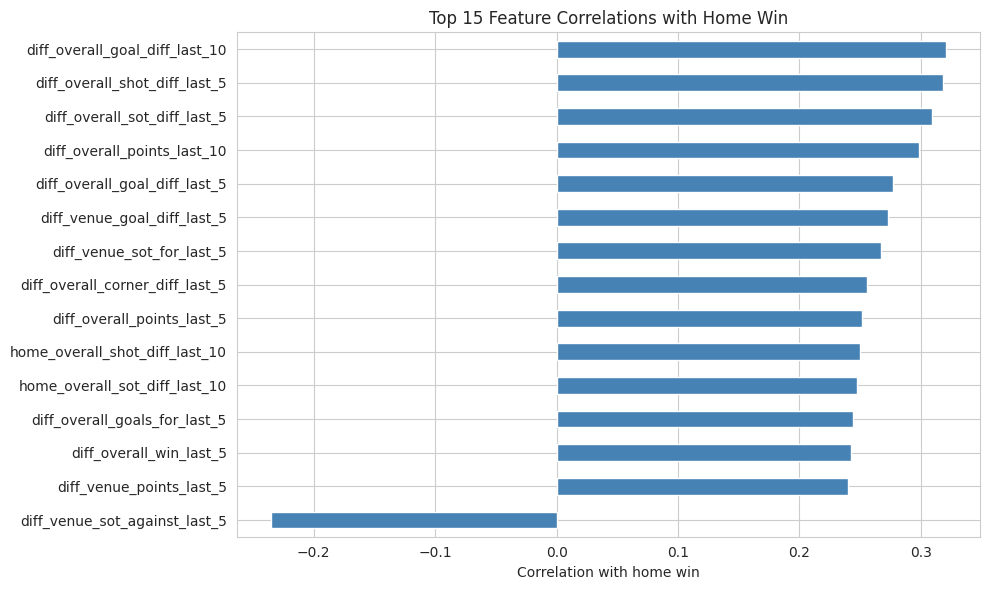

In [12]:
top_corr = corr_home.head(15)

plt.figure(figsize=(10, 6))
top_corr.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Correlation with home win")
plt.title("Top 15 Feature Correlations with Home Win")
plt.tight_layout()
plt.show()

In [13]:
diff_cols = [c for c in numeric.columns if c.startswith("diff_")]
home_away_cols = [c for c in numeric.columns if c.startswith(("home_", "away_"))]

print(f"Mean |correlation| of diff_ features:      {corr_home[diff_cols].abs().mean():.3f}")
print(f"Mean |correlation| of home_/away_ features: {corr_home[home_away_cols].abs().mean():.3f}")

Mean |correlation| of diff_ features:      0.229
Mean |correlation| of home_/away_ features: 0.142


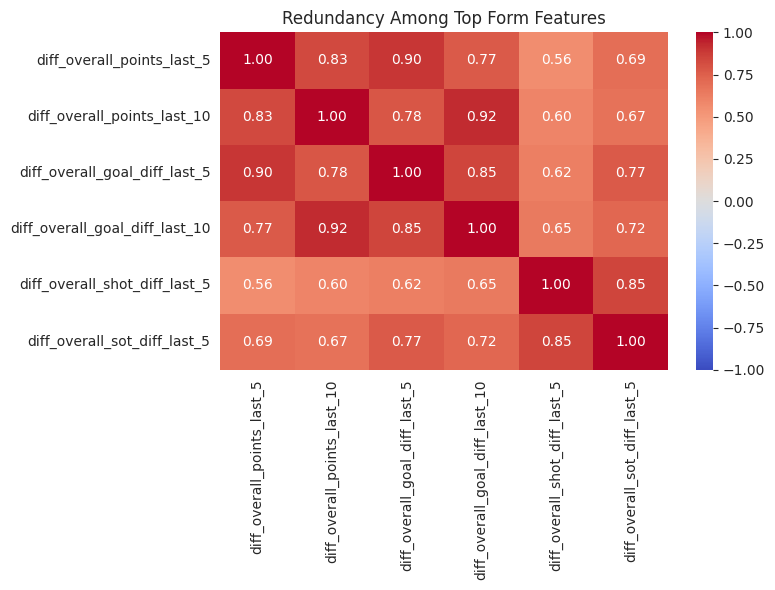

In [14]:
redundancy_cols = [
    "diff_overall_points_last_5", "diff_overall_points_last_10",
    "diff_overall_goal_diff_last_5", "diff_overall_goal_diff_last_10",
    "diff_overall_shot_diff_last_5", "diff_overall_sot_diff_last_5",
]
plt.figure(figsize=(8, 6))
sns.heatmap(model_rows[redundancy_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Redundancy Among Top Form Features")
plt.tight_layout()
plt.show()

### Findings

- Differential features (home form minus away form) dominate the ranking and are on average clearly stronger than the raw one-sided features. This validates the core feature-engineering decision.
- The best single features reach r of about 0.32 with home wins: individually weak, but there are many partially independent ones, which is the regime where tree ensembles and regularized linear models do well.
- The last-5 and last-10 versions of the same statistic, and points vs goal-difference measures, are highly inter-correlated. The roughly 150-column feature set contains substantial redundancy; expect regularization or feature selection to trim it with little performance cost.

## 9. Pre-Modeling Data Quality Checks

In [15]:
print(f"Warm-up rows with missing form features: {warm_up.sum()} of {len(features)} ({warm_up.mean() * 100:.1f}%)")
print(f"All warm-up rows are in season: {features.loc[warm_up, 'Season'].unique()}")

leak_cols = [col for col in features.columns if col in ("FTHG", "FTAG", "FTR")]
print(f"\nPost-match columns present in the feature file: {leak_cols}")

Warm-up rows with missing form features: 24 of 3800 (0.6%)
All warm-up rows are in season: <StringArray>
['2016_2017', '2017_2018', '2018_2019', '2019_2020', '2020_2021', '2021_2022',
 '2022_2023', '2023_2024', '2024_2025']
Length: 9, dtype: str

Post-match columns present in the feature file: ['FTHG', 'FTAG', 'FTR']


### Findings

- 24 rows (0.6%) at the very start of the earliest season have no match history and therefore NaN form features. Recommendation: drop them; they are too few to justify imputation.
- `FTHG`, `FTAG`, and `FTR` are carried in the feature file alongside the encoded targets. Fine as reference columns, but they and all `target_*` columns must be explicitly excluded from the training matrix to avoid label leakage.
- Because rows are ordered in time and features are rolling, all model validation must use a chronological split (train on earlier seasons, test on later ones). A random shuffle split would leak future form information.

## 10. Key Findings

- Goals are low-frequency events (about 2.8 per match, mostly tight scorelines), so single-match outcomes carry irreducible randomness; probabilistic metrics matter.
- In-match dominance statistics, especially shots on target, separate outcomes cleanly, justifying rolling-form features built from them.
- Home advantage comes from shot volume, not finishing quality.
- Draws are the weak point: no feature correlates with draws above about |r| = 0.06, so per-class evaluation is essential and draw-specific strategies are worth exploring.
- Differential (home minus away) form features are the strongest group, peaking around r = 0.32 with home wins, but the feature set is highly redundant.
- Before modeling: drop the 24 warm-up rows, exclude `FTHG`/`FTAG`/`FTR`/`target_*` from the training matrix, and validate with a strictly chronological split.

## 11. Next Steps

- Establish baselines: majority class (about 43%) and, if bookmaker odds from the raw files are reintroduced, the bookmaker-favorite baseline as an upper reference.
- Train a first model (regularized logistic regression and a gradient-boosted tree) on the differential feature group, evaluated with accuracy, log loss, and per-class recall on a chronological holdout.
- Revisit draw handling once baseline results are in.